In [81]:
class Bruteforceindex:
  def __init__(self):
    self.data=[]
  def insert(self,key,value):
    found,a=self.search(key)
    if found:
      self.update(key,value)
    else:
      self.data.append((key,value))
  def search(self,key):
    for k,v in self.data:
      if k==key:
        return (True,v)
    return (False,None)
  def delete(self,key):
    for i,(k,v) in enumerate(self.data):
      if k==key:
        self.data.pop(i)
        return True
    return False
  def update(self,key,newval):
    for i,(k,v) in enumerate(self.data):
      if k==key:
        self.data[i]=(k,newval)
        return True
    return False
  def getall(self):
    return self.data.copy()
  def range_query(self,st,end):
    return [i for i in self.data if st<=i[0]<=end]


# Task-1

**Defining bplustreenode and bplustree classes**

In [83]:
class bplustreenode:
    def __init__(self, is_leaf=False):
        self.is_leaf = is_leaf
        self.keys = []
        self.children = []   # internal nodes
        self.values = []     # leaf nodes
        self.next = None     # leaf linkage


class bplustree:
    def __init__(self, degree=4):
        self.root = bplustreenode(True)
        self.degree = degree
        self.min_keys = (degree + 1) // 2 - 1   # for degree=4 -> 1

    
    # Search 
    
    def search(self, key):
        node = self.root
        while not node.is_leaf:
            i = 0
            while i < len(node.keys) and key >= node.keys[i]:
                i += 1
            node = node.children[i]

        for i, item in enumerate(node.keys):
            if item == key:
                return (True, node.values[i])
        return (False, None)
    #Update
    def update(self, key, new_value):
        node = self.root
        while not node.is_leaf:
            i = 0
            while i < len(node.keys) and key >= node.keys[i]:
                i += 1
            node = node.children[i]

        for i, item in enumerate(node.keys):
            if item == key:
                node.values[i] = new_value
                return True
        return False

    # Insert
    def insert(self, key, value):
        found,_ = self.search(key)
        if found:
          b=self.update(key,value)
          return
        if len(self.root.keys) == self.degree - 1:
            new_root = bplustreenode(is_leaf=False)
            new_root.children.append(self.root)
            self._split_child(new_root, 0)
            self.root = new_root

        self._insert_non_full(self.root, key, value)
        self._refresh_internal_keys(self.root)

    def _insert_non_full(self, node, key, value):
        if node.is_leaf:
            idx = 0
            while idx < len(node.keys) and key > node.keys[idx]:
                idx += 1
            node.keys.insert(idx, key)
            node.values.insert(idx, value)
        else:
            idx = 0
            while idx < len(node.keys) and key > node.keys[idx]:
                idx += 1

            if len(node.children[idx].keys) == self.degree - 1:
                self._split_child(node, idx)
                if idx < len(node.keys) and key >= node.keys[idx]:
                    idx += 1

            self._insert_non_full(node.children[idx], key, value)

    def _split_child(self, parent, index):
        node = parent.children[index]
        new_node = bplustreenode(is_leaf=node.is_leaf)

        if node.is_leaf:
            mid = len(node.keys) // 2

            new_node.keys = node.keys[mid:]
            new_node.values = node.values[mid:]

            node.keys = node.keys[:mid]
            node.values = node.values[:mid]

            parent.keys.insert(index, new_node.keys[0])
            parent.children.insert(index + 1, new_node)

            new_node.next = node.next
            node.next = new_node

        else:
            mid = len(node.keys) // 2

            up_key = node.keys[mid]

            new_node.keys = node.keys[mid + 1:]
            new_node.children = node.children[mid + 1:]

            node.keys = node.keys[:mid]
            node.children = node.children[:mid + 1]

            parent.keys.insert(index, up_key)
            parent.children.insert(index + 1, new_node)

    
    # Range query 
    def range_query(self, st, end):
        node = self.root
        while not node.is_leaf:
            i = 0
            while i < len(node.keys) and st >= node.keys[i]:
                i += 1
            node = node.children[i]

        result = []
        while node is not None:
            for i, key in enumerate(node.keys):
                if st <= key <= end:
                    result.append((key, node.values[i]))
                elif key > end:
                    return result
            node = node.next
        return result

    def get_all(self):
        result = []
        node = self.root
        while not node.is_leaf:
            node = node.children[0]

        while node:
            for key, value in zip(node.keys, node.values):
                result.append((key, value))
            node = node.next
        return result

    
    # Delete
    
    def delete(self, key):
        if not self.root or len(self.root.keys) == 0 and self.root.is_leaf:
            return False

        deleted = self._delete(self.root, key)

        if deleted:
            # Fix empty internal root
            while not self.root.is_leaf and len(self.root.keys) == 0 and self.root.children:
                self.root = self.root.children[0]

            self._refresh_internal_keys(self.root)

        return deleted

    def _delete(self, node, key):
        if node.is_leaf:
            if key in node.keys:
                idx = node.keys.index(key)
                node.keys.pop(idx)
                node.values.pop(idx)
                return True
            return False

        idx = 0
        while idx < len(node.keys) and key >= node.keys[idx]:
            idx += 1

        if len(node.children[idx].keys) == self.min_keys:
            idx = self._fill_child(node, idx)

        return self._delete(node.children[idx], key)

    def _fill_child(self, node, idx):
        # borrow from left sibling
        if idx > 0 and len(node.children[idx - 1].keys) > self.min_keys:
            self._borrow_from_prev(node, idx)
            return idx

        # borrow from right sibling
        if idx < len(node.children) - 1 and len(node.children[idx + 1].keys) > self.min_keys:
            self._borrow_from_next(node, idx)
            return idx

        # merge
        if idx < len(node.children) - 1:
            self._merge(node, idx)
            return idx
        else:
            self._merge(node, idx - 1)
            return idx - 1

    def _borrow_from_prev(self, node, index):
        child = node.children[index]
        sibling = node.children[index - 1]

        if child.is_leaf:
            child.keys.insert(0, sibling.keys.pop(-1))
            child.values.insert(0, sibling.values.pop(-1))
        else:
            child.keys.insert(0, node.keys[index - 1])
            node.keys[index - 1] = sibling.keys.pop(-1)
            child.children.insert(0, sibling.children.pop(-1))

    def _borrow_from_next(self, node, index):
        child = node.children[index]
        sibling = node.children[index + 1]

        if child.is_leaf:
            child.keys.append(sibling.keys.pop(0))
            child.values.append(sibling.values.pop(0))
        else:
            child.keys.append(node.keys[index])
            node.keys[index] = sibling.keys.pop(0)
            child.children.append(sibling.children.pop(0))

    def _merge(self, node, index):
        child = node.children[index]
        sibling = node.children[index + 1]

        if child.is_leaf:
            child.keys.extend(sibling.keys)
            child.values.extend(sibling.values)
            child.next = sibling.next
        else:
            child.keys.append(node.keys[index])
            child.keys.extend(sibling.keys)
            child.children.extend(sibling.children)

        node.keys.pop(index)
        node.children.pop(index + 1)

    
    # Rebuild internal separators
    
    def _leftmost_key(self, node):
        while node and not node.is_leaf:
            node = node.children[0]
        if node and node.keys:
            return node.keys[0]
        return None

    def _refresh_internal_keys(self, node):
        if node is None or node.is_leaf:
            return

        for child in node.children:
            self._refresh_internal_keys(child)

        new_keys = []
        for child in node.children[1:]:
            k = self._leftmost_key(child)
            if k is not None:
                new_keys.append(k)

        node.keys = new_keys

  
    # Visualization
   
    def visualize_tree(self, filename="bplustree"):
        dot = Digraph(format='png')
        dot.attr(dpi='300')
        dot.attr(rankdir='TB')

        self._add_nodes(dot, self.root)
        self._add_edges(dot, self.root)

        # Add dashed leaf links
        leaf = self.root
        while leaf and not leaf.is_leaf:
            leaf = leaf.children[0] if leaf.children else None

        while leaf and leaf.next:
            dot.edge(
                str(id(leaf)),
                str(id(leaf.next)),
                style='dashed',
                color='red',
                constraint='false'
            )
            leaf = leaf.next

        dot.render(filename, cleanup=True)
        return dot

    def _add_nodes(self, dot, node):
        if node is None:
            return

        node_id = str(id(node))
        label = " | ".join(str(k) for k in node.keys) if node.keys else "∅"

        if node.is_leaf:
            dot.node(node_id, label=label, shape="box", style="filled", color="lightblue")
        else:
            dot.node(node_id, label=label, shape="box", style="filled", color="lightgray")

        if not node.is_leaf:
            for child in node.children:
                self._add_nodes(dot, child)

    def _add_edges(self, dot, node):
        if node is None or node.is_leaf:
            return

        parent_id = str(id(node))
        for child in node.children:
            dot.edge(parent_id, str(id(child)))
            self._add_edges(dot, child)


**Implementation of insertion, deletion, search, and range queries.**

In [85]:
def run_bplus_tree():
    print("creating B+ Tree")
    #creating tree with order=4
    tree=bplustree(4)
    
    #inserting key-value pairs
    print("\nInserting items:")
    for k in [10, 20, 30, 40, 50, 60, 90, 100, 110]:
        print(f"Inserting key {k} with value DATA1")
        tree.insert(k, "DATA1")


    for k in [5, 25, 35, 75, 85, 95, 105, 115]:
        print(f"Inserting key {k} with value DATA2")
        tree.insert(k, "DATA2")


    for k in [7, 17, 37, 47, 57]:
        print(f"Inserting key {k} with value DATA3")
        tree.insert(k, "DATA3")

    #searching for existing and non-existing keys
    print("\nsearching 30,47,65 if existing in tree")
    search_keys = [30, 47, 65]
    for key in search_keys:
        found, value = tree.search(key)
        if found:
            print(f"Key {key} found with value '{value}'")
        else:
            print(f"Key {key} not found.")
    #  Range Query
    print("\nRange Query (keys between 20 and 58):")
    result = tree.range_query(20, 58)
    print(result)
    
    #  Updating a value 
    print("\nUpdating key 57 to new value 'updated-57'")
    tree.update(57, "updated-57")
    print(tree.get_all())
    # 5. Deleting keys 
    keys_to_delete = [17,35,105,40]
    print("\nDeleting keys one by one:")
    for key in keys_to_delete:
        print(f"Deleting key {key}")
        tree.delete(key)
        print("Current keys:", tree.get_all())

run_bplus_tree()

creating B+ Tree

Inserting items:
Inserting key 10 with value DATA1
Inserting key 20 with value DATA1
Inserting key 30 with value DATA1
Inserting key 40 with value DATA1
Inserting key 50 with value DATA1
Inserting key 60 with value DATA1
Inserting key 90 with value DATA1
Inserting key 100 with value DATA1
Inserting key 110 with value DATA1
Inserting key 5 with value DATA2
Inserting key 25 with value DATA2
Inserting key 35 with value DATA2
Inserting key 75 with value DATA2
Inserting key 85 with value DATA2
Inserting key 95 with value DATA2
Inserting key 105 with value DATA2
Inserting key 115 with value DATA2
Inserting key 7 with value DATA3
Inserting key 17 with value DATA3
Inserting key 37 with value DATA3
Inserting key 47 with value DATA3
Inserting key 57 with value DATA3

searching 30,47,65 if existing in tree
Key 30 found with value 'DATA1'
Key 47 found with value 'DATA3'
Key 65 not found.

Range Query (keys between 20 and 58):
[(20, 'DATA1'), (25, 'DATA2'), (30, 'DATA1'), (35, 'DA

# Task 2

**performance analyzer class**

In [87]:
class PerformanceAnalyzer:
    def __init__(self, ds):
        self.ds = ds

    def measure_time_memory(self, func, *args):
        tracemalloc.start()
        start = time.perf_counter()

        func(*args)

        end = time.perf_counter()
        current, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        return end - start, peak / 1024  # KB

    # Bulk operations
    def insert_bulk(self, keys):
        for k in keys:
            self.ds.insert(k, str(k))

    def search_bulk(self, keys):
        for k in keys:
            self.ds.search(k)

    def delete_bulk(self, keys):
        for k in keys:
            self.ds.delete(k)

    def range_bulk(self, ranges):
        for l, r in ranges:
            self.ds.range_query(l, r)
    

# Task 3

**visualizing the tree**

In [89]:
!pip install graphviz
from graphviz import Digraph
tree = bplustree(4)

for i in range(1, 20):
    tree.insert(i, str(i))
dot = tree.visualize_tree()
dot.render("bplustree", view=True)
#print("below picture is pasted after downloading the picture from code")

#leaf nodes are linked as shown using red arrow
#gray boxes are internal nodes except the root
#black arrows direct toward their child from the respective node

'bplustree.png'

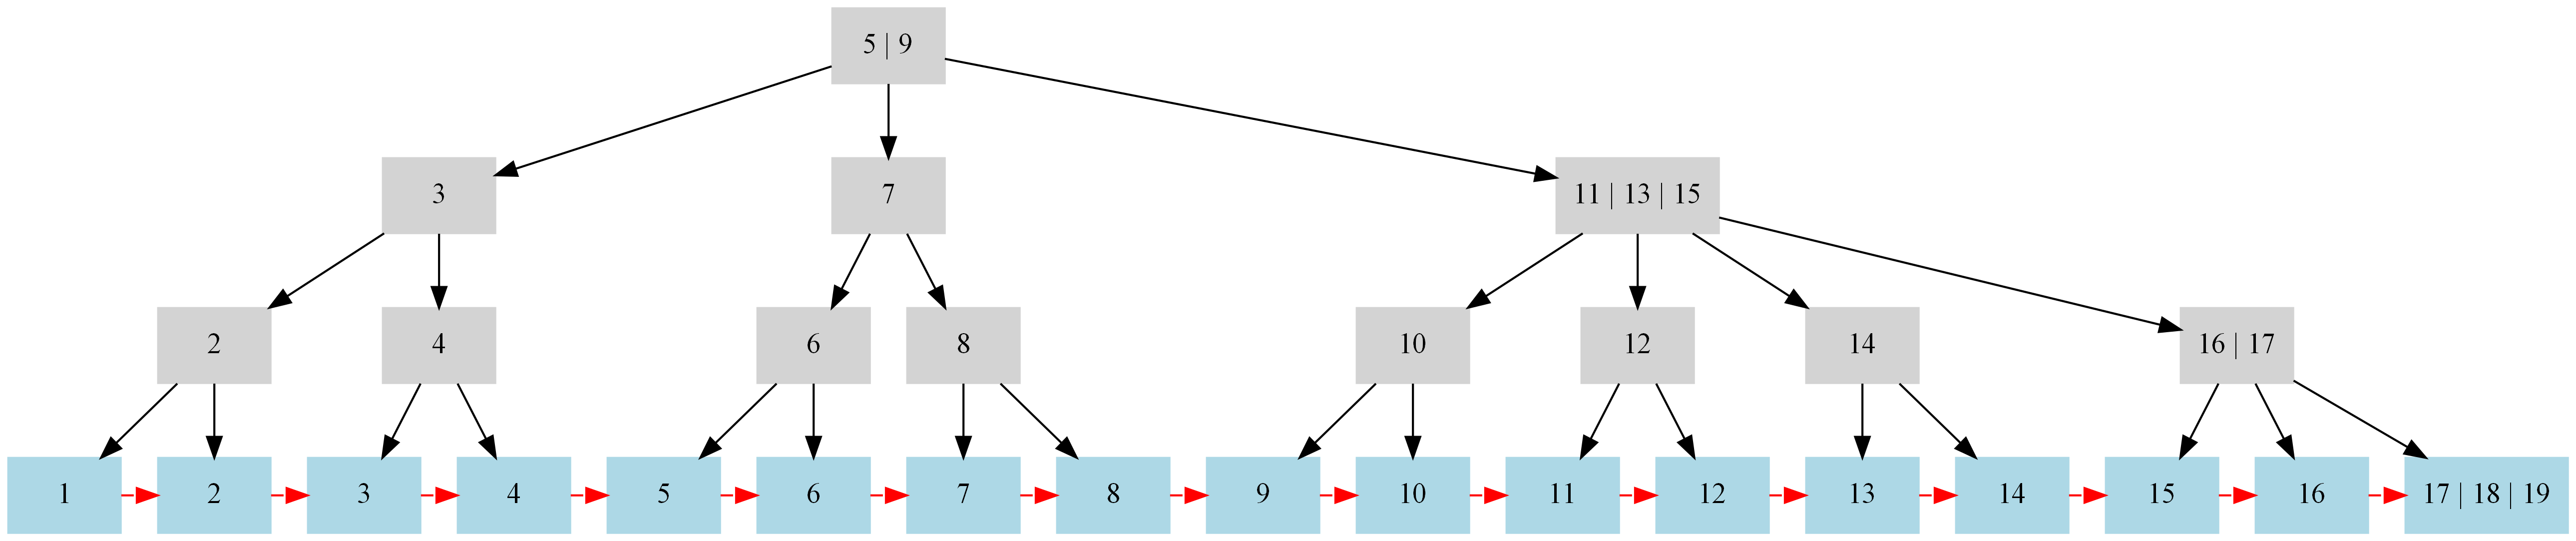

# Task 4

**Conduct Performance Testing**

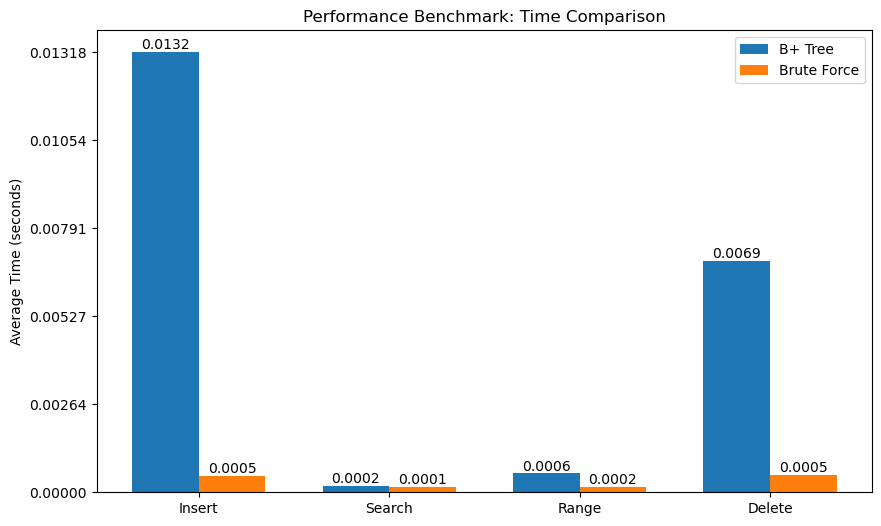

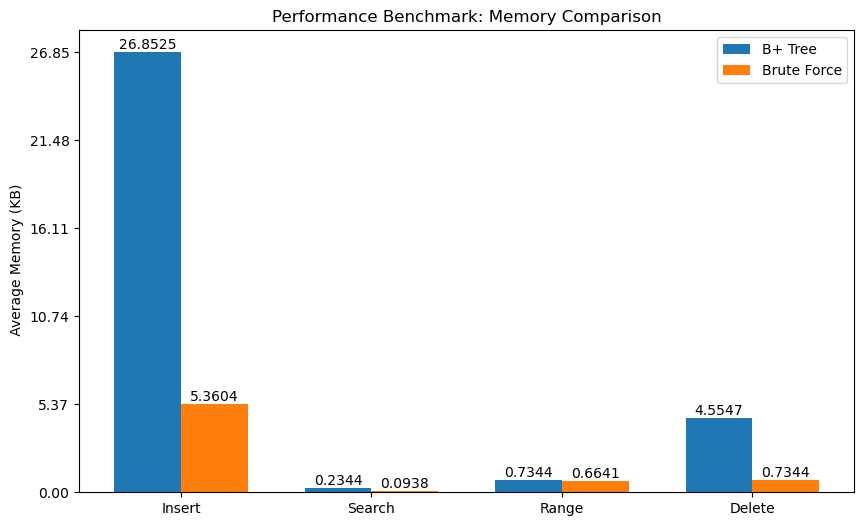

In [91]:
import random
import time
import tracemalloc
import matplotlib.pyplot as plt
import numpy as np

# Data Generator

def generate_data(size):
    keys = random.sample(range(size * 10), size)
    search_keys = random.sample(keys, size // 2)
    delete_keys = random.sample(keys, size // 2)

    ranges = []
    for _ in range(size // 10):
        a, b = random.randint(0, size*10), random.randint(0, size*10)
        ranges.append((min(a, b), max(a, b)))

    return keys, search_keys, delete_keys, ranges


# -----------------------------
# Run Test for size=100
# -----------------------------
size = 100
keys, search_keys, delete_keys, ranges = generate_data(size)

operations = ["Insert", "Search", "Range", "Delete"]

# -------- B+ TREE --------
bpt = bplustree(4)
an_bpt = PerformanceAnalyzer(bpt)

time_bpt = []
mem_bpt = []

t, m = an_bpt.measure_time_memory(an_bpt.insert_bulk, keys)
time_bpt.append(t); mem_bpt.append(m)

t, m = an_bpt.measure_time_memory(an_bpt.search_bulk, search_keys)
time_bpt.append(t); mem_bpt.append(m)

t, m = an_bpt.measure_time_memory(an_bpt.range_bulk, ranges)
time_bpt.append(t); mem_bpt.append(m)

t, m = an_bpt.measure_time_memory(an_bpt.delete_bulk, delete_keys)
time_bpt.append(t); mem_bpt.append(m)


# -------- BRUTE FORCE --------
bf = Bruteforceindex()
an_bf = PerformanceAnalyzer(bf)

time_bf = []
mem_bf = []

t, m = an_bf.measure_time_memory(an_bf.insert_bulk, keys)
time_bf.append(t); mem_bf.append(m)

t, m = an_bf.measure_time_memory(an_bf.search_bulk, search_keys)
time_bf.append(t); mem_bf.append(m)

t, m = an_bf.measure_time_memory(an_bf.range_bulk, ranges)
time_bf.append(t); mem_bf.append(m)

t, m = an_bf.measure_time_memory(an_bf.delete_bulk, delete_keys)
time_bf.append(t); mem_bf.append(m)



# Plotting Function
def plot_histogram(values1, values2, ylabel, title):
    x = np.arange(len(operations))
    width = 0.35

    plt.figure(figsize=(10,6))

    bars1 = plt.bar(x - width/2, values1, width, label="B+ Tree")
    bars2 = plt.bar(x + width/2, values2, width, label="Brute Force")

   
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(x, operations)
    plt.legend()

    # Y-axis ticks spacing
    max_val = max(values1 + values2)
    plt.yticks(np.linspace(0, max_val, 6))

    # Value labels on top
    def add_labels(bars):
        for bar in bars:
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width()/2,
                height,
                f"{height:.4f}",
                ha='center',
                va='bottom'
            )

    add_labels(bars1)
    add_labels(bars2)

    plt.show()


# PLOTS


# TIME histogram
plot_histogram(time_bpt, time_bf,
               ylabel="Average Time (seconds)",
               title="Performance Benchmark: Time Comparison")

# MEMORY histogram
plot_histogram(mem_bpt, mem_bf,
               ylabel=" Average Memory (KB)",
               title="Performance Benchmark: Memory Comparison")

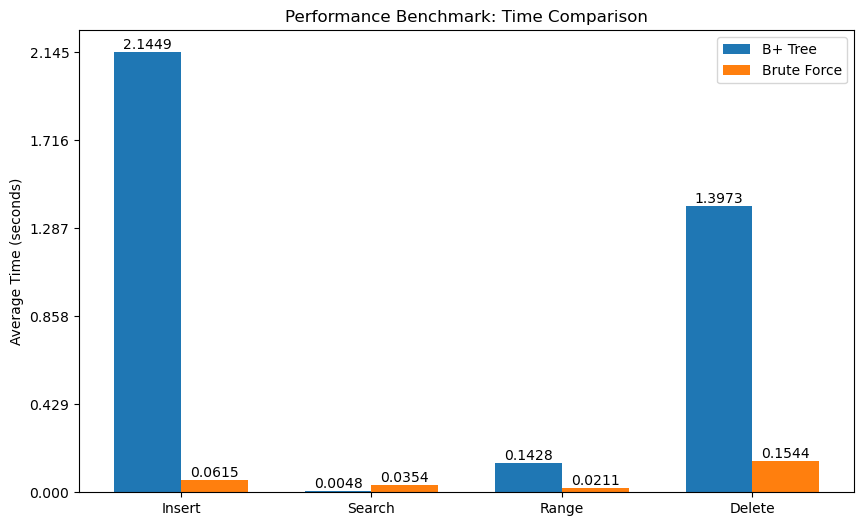

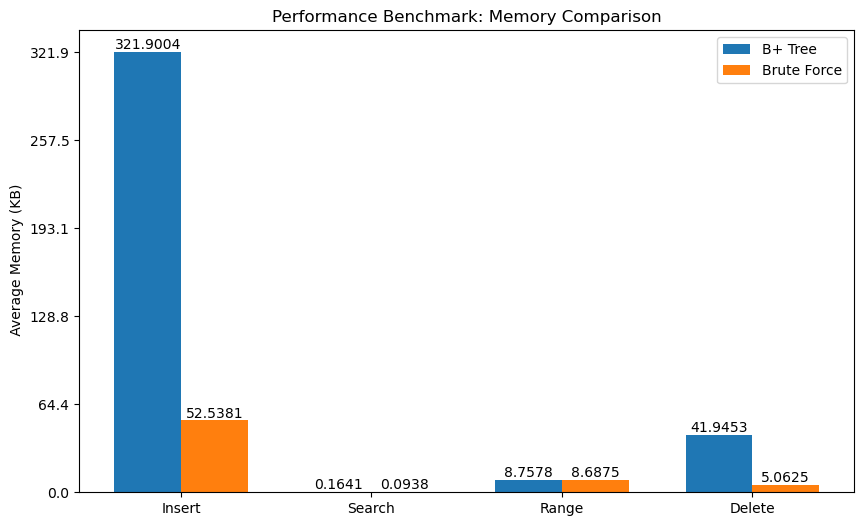

In [69]:
import random
import time
import tracemalloc
import matplotlib.pyplot as plt
import numpy as np

# Data Generator

def generate_data(size):
    keys = random.sample(range(size * 10), size)
    search_keys = random.sample(keys, size // 2)
    delete_keys = random.sample(keys, size // 2)

    ranges = []
    for _ in range(size // 10):
        a, b = random.randint(0, size*10), random.randint(0, size*10)
        ranges.append((min(a, b), max(a, b)))

    return keys, search_keys, delete_keys, ranges


# -----------------------------
# Run Test for size=1000
# -----------------------------
size = 1000
keys, search_keys, delete_keys, ranges = generate_data(size)

operations = ["Insert", "Search", "Range", "Delete"]

# -------- B+ TREE --------
bpt = bplustree(4)
an_bpt = PerformanceAnalyzer(bpt)

time_bpt = []
mem_bpt = []

t, m = an_bpt.measure_time_memory(an_bpt.insert_bulk, keys)
time_bpt.append(t); mem_bpt.append(m)

t, m = an_bpt.measure_time_memory(an_bpt.search_bulk, search_keys)
time_bpt.append(t); mem_bpt.append(m)

t, m = an_bpt.measure_time_memory(an_bpt.range_bulk, ranges)
time_bpt.append(t); mem_bpt.append(m)

t, m = an_bpt.measure_time_memory(an_bpt.delete_bulk, delete_keys)
time_bpt.append(t); mem_bpt.append(m)


# -------- BRUTE FORCE --------
bf = Bruteforceindex()
an_bf = PerformanceAnalyzer(bf)

time_bf = []
mem_bf = []

t, m = an_bf.measure_time_memory(an_bf.insert_bulk, keys)
time_bf.append(t); mem_bf.append(m)

t, m = an_bf.measure_time_memory(an_bf.search_bulk, search_keys)
time_bf.append(t); mem_bf.append(m)

t, m = an_bf.measure_time_memory(an_bf.range_bulk, ranges)
time_bf.append(t); mem_bf.append(m)

t, m = an_bf.measure_time_memory(an_bf.delete_bulk, delete_keys)
time_bf.append(t); mem_bf.append(m)



# Plotting Function
def plot_histogram(values1, values2, ylabel, title):
    x = np.arange(len(operations))
    width = 0.35

    plt.figure(figsize=(10,6))

    bars1 = plt.bar(x - width/2, values1, width, label="B+ Tree")
    bars2 = plt.bar(x + width/2, values2, width, label="Brute Force")

   
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(x, operations)
    plt.legend()

    # Y-axis ticks spacing
    max_val = max(values1 + values2)
    plt.yticks(np.linspace(0, max_val, 6))

    # Value labels on top
    def add_labels(bars):
        for bar in bars:
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width()/2,
                height,
                f"{height:.4f}",
                ha='center',
                va='bottom'
            )

    add_labels(bars1)
    add_labels(bars2)

    plt.show()


# PLOTS


# TIME histogram
plot_histogram(time_bpt, time_bf,
               ylabel="Average Time (seconds)",
               title="Performance Benchmark: Time Comparison")

# MEMORY histogram
plot_histogram(mem_bpt, mem_bf,
               ylabel=" Average Memory (KB)",
               title="Performance Benchmark: Memory Comparison")

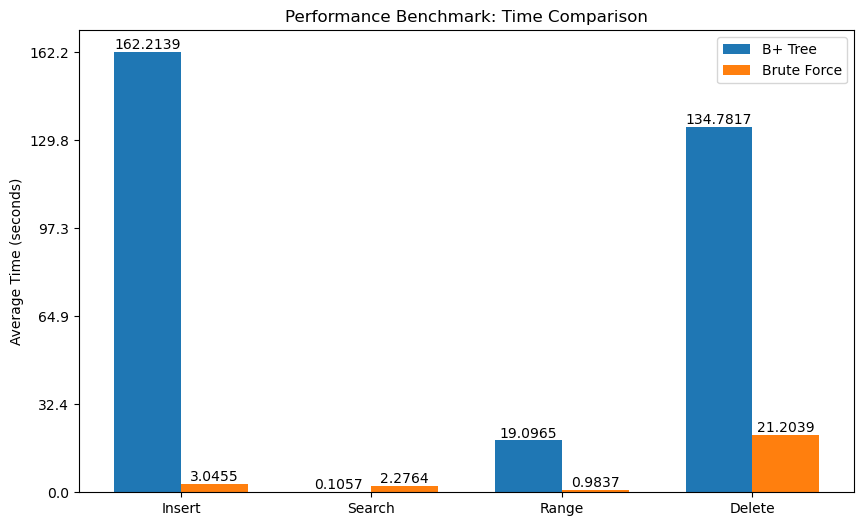

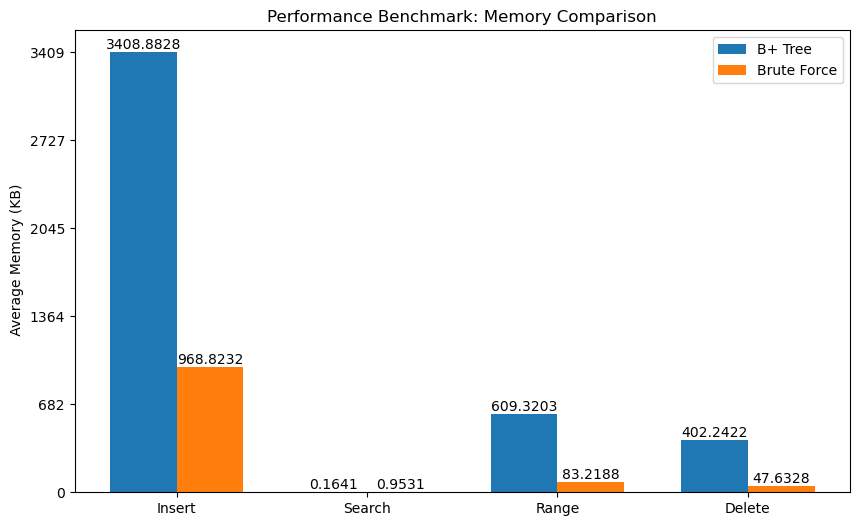

In [93]:
import random
import time
import tracemalloc
import matplotlib.pyplot as plt
import numpy as np

# Data Generator

def generate_data(size):
    keys = random.sample(range(size * 10), size)
    search_keys = random.sample(keys, size // 2)
    delete_keys = random.sample(keys, size // 2)

    ranges = []
    for _ in range(size // 10):
        a, b = random.randint(0, size*10), random.randint(0, size*10)
        ranges.append((min(a, b), max(a, b)))

    return keys, search_keys, delete_keys, ranges



# Run Test for size=10000

size = 10000
keys, search_keys, delete_keys, ranges = generate_data(size)

operations = ["Insert", "Search", "Range", "Delete"]

# -------- B+ TREE --------
bpt = bplustree(4)
an_bpt = PerformanceAnalyzer(bpt)

time_bpt = []
mem_bpt = []

t, m = an_bpt.measure_time_memory(an_bpt.insert_bulk, keys)
time_bpt.append(t); mem_bpt.append(m)

t, m = an_bpt.measure_time_memory(an_bpt.search_bulk, search_keys)
time_bpt.append(t); mem_bpt.append(m)

t, m = an_bpt.measure_time_memory(an_bpt.range_bulk, ranges)
time_bpt.append(t); mem_bpt.append(m)

t, m = an_bpt.measure_time_memory(an_bpt.delete_bulk, delete_keys)
time_bpt.append(t); mem_bpt.append(m)


# -------- BRUTE FORCE --------
bf = Bruteforceindex()
an_bf = PerformanceAnalyzer(bf)

time_bf = []
mem_bf = []

t, m = an_bf.measure_time_memory(an_bf.insert_bulk, keys)
time_bf.append(t); mem_bf.append(m)

t, m = an_bf.measure_time_memory(an_bf.search_bulk, search_keys)
time_bf.append(t); mem_bf.append(m)

t, m = an_bf.measure_time_memory(an_bf.range_bulk, ranges)
time_bf.append(t); mem_bf.append(m)

t, m = an_bf.measure_time_memory(an_bf.delete_bulk, delete_keys)
time_bf.append(t); mem_bf.append(m)



# Plotting Function
def plot_histogram(values1, values2, ylabel, title):
    x = np.arange(len(operations))
    width = 0.35

    plt.figure(figsize=(10,6))

    bars1 = plt.bar(x - width/2, values1, width, label="B+ Tree")
    bars2 = plt.bar(x + width/2, values2, width, label="Brute Force")

   
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(x, operations)
    plt.legend()

    # Y-axis ticks spacing
    max_val = max(values1 + values2)
    plt.yticks(np.linspace(0, max_val, 6))

    # Value labels on top
    def add_labels(bars):
        for bar in bars:
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width()/2,
                height,
                f"{height:.4f}",
                ha='center',
                va='bottom'
            )

    add_labels(bars1)
    add_labels(bars2)

    plt.show()


# PLOTS


# TIME histogram
plot_histogram(time_bpt, time_bf,
               ylabel="Average Time (seconds)",
               title="Performance Benchmark: Time Comparison")

# MEMORY histogram
plot_histogram(mem_bpt, mem_bf,
               ylabel=" Average Memory (KB)",
               title="Performance Benchmark: Memory Comparison")

Running size = 1000
Running size = 2000
Running size = 3000
Running size = 4000
Running size = 5000
Running size = 6000
Running size = 7000
Running size = 8000
Running size = 9000
Running size = 10000


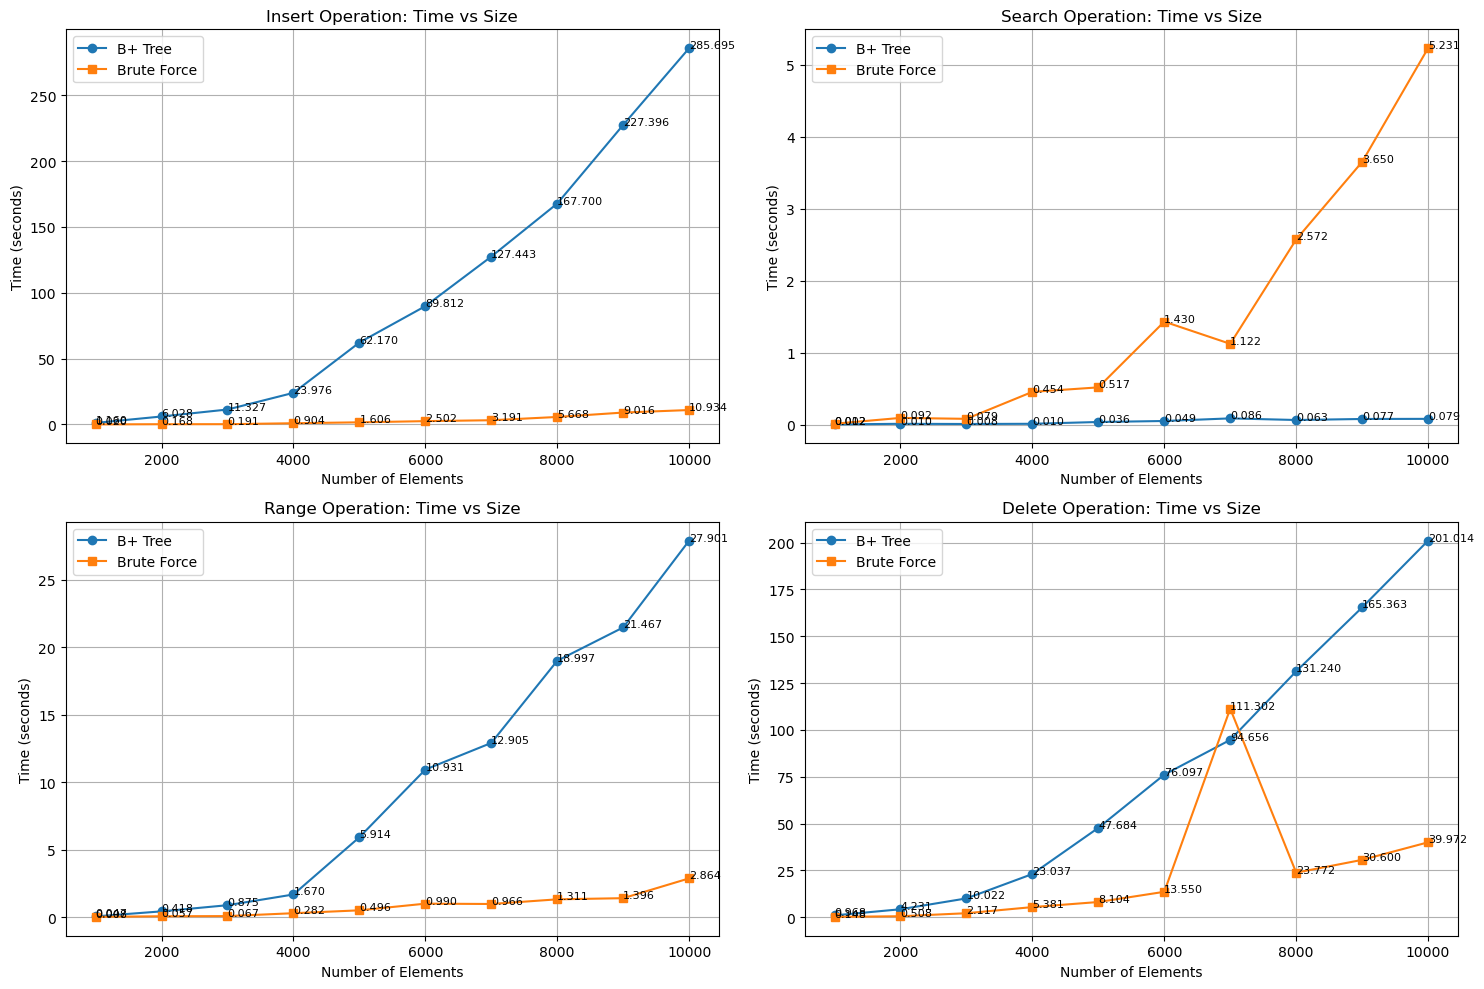

In [94]:
import matplotlib.pyplot as plt
import random
import time

# --- DATA GENERATOR ---
def generate_data(size):
    keys = random.sample(range(size * 10), size)
    search_keys = random.sample(keys, size // 2)
    delete_keys = random.sample(keys, size // 2)

    ranges = []
    for _ in range(size // 10):
        a, b = random.randint(0, size * 10), random.randint(0, size * 10)
        ranges.append((min(a, b), max(a, b)))

    return keys, search_keys, delete_keys, ranges

# --- EXPERIMENT SETUP ---
sizes = list(range(1000, 10001, 1000))
bpt_times = {"insert": [], "search": [], "range": [], "delete": []}
bf_times = {"insert": [], "search": [], "range": [], "delete": []}

# --- RUN EXPERIMENT ---
for size in sizes:
    print(f"Running size = {size}")
    keys, search_keys, delete_keys, ranges = generate_data(size)

    # B+ TREE (Assumes your bplustree and PerformanceAnalyzer classes are defined)
    bpt = bplustree(4)
    an_bpt = PerformanceAnalyzer(bpt)
    bpt_times["insert"].append(an_bpt.measure_time_memory(an_bpt.insert_bulk, keys)[0])
    bpt_times["search"].append(an_bpt.measure_time_memory(an_bpt.search_bulk, search_keys)[0])
    bpt_times["range"].append(an_bpt.measure_time_memory(an_bpt.range_bulk, ranges)[0])
    bpt_times["delete"].append(an_bpt.measure_time_memory(an_bpt.delete_bulk, delete_keys)[0])

    # BRUTE FORCE (Assumes your Bruteforceindex class is defined)
    bf = Bruteforceindex()
    an_bf = PerformanceAnalyzer(bf)
    bf_times["insert"].append(an_bf.measure_time_memory(an_bf.insert_bulk, keys)[0])
    bf_times["search"].append(an_bf.measure_time_memory(an_bf.search_bulk, search_keys)[0])
    bf_times["range"].append(an_bf.measure_time_memory(an_bf.range_bulk, ranges)[0])
    bf_times["delete"].append(an_bf.measure_time_memory(an_bf.delete_bulk, delete_keys)[0])

# --- GENERATE 2x2 SUBPLOTS ---
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()  # Convert 2D grid to 1D list for easy looping
operations = ["insert", "search", "range", "delete"]

for i, op in enumerate(operations):
    ax = axes[i]
    
    ax.plot(sizes, bpt_times[op], marker='o', label="B+ Tree")
    ax.plot(sizes, bf_times[op], marker='s', label="Brute Force")

    ax.set_xlabel("Number of Elements")
    ax.set_ylabel("Time (seconds)")
    ax.set_title(f"{op.capitalize()} Operation: Time vs Size")
    ax.legend()
    ax.grid(True)

    # Annotate values
    for x, y in zip(sizes, bpt_times[op]):
        ax.text(x, y, f"{y:.3f}", fontsize=8)
    for x, y in zip(sizes, bf_times[op]):
        ax.text(x, y, f"{y:.3f}", fontsize=8)

# Prevent labels from overlapping
plt.tight_layout()
plt.show()

In [ ]:
from db_manager import Database